In [4]:
# Import required libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load only Age, Fare and Survived columns from the Titanic dataset
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])

In [6]:
# Preview first 5 rows
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
# Check what percentage of values are missing in each column
# Age has ~20% missing values — a good candidate for random sample imputation
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [8]:
# Separate features (X) and target label (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

In [9]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [10]:
# View training data — notice NaN values in Age column
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [11]:
# Create a copy of Age column called Age_imputed
# We will fill NaN values in Age_imputed while keeping original Age column unchanged
# This lets us compare before and after imputation
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [12]:
# Check test data tail — Age_imputed still has NaN (same as Age)
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [13]:
# How many missing values are in Age column of training data?
X_train['Age'].isnull().sum()

np.int64(148)

In [ ]:
# What does random sample imputation do?
# Instead of filling NaN with mean/median (a single fixed value),
# it picks RANDOM values from the existing non-null Age values
# This preserves the original distribution of the data better

# count how many values are missing
train_missing = X_train['Age_imputed'].isnull().sum()
test_missing  = X_test['Age_imputed'].isnull().sum()

# randomly pick that many values from non-null Age in training data
train_samples = X_train['Age'].dropna().sample(train_missing).values
test_samples  = X_train['Age'].dropna().sample(test_missing).values  # always sample from train, not test

# fill the missing spots using .loc (avoids chained assignment warning)
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = train_samples
X_test.loc[X_test['Age_imputed'].isnull(),   'Age_imputed'] = test_samples

In [15]:
# See what values were randomly sampled to fill the missing Age values
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([23.  , 19.  , 38.  , 16.  , 25.  , 29.  ,  3.  , 18.  , 43.  ,
       24.  , 28.  , 32.  , 52.  , 21.  , 21.  , 22.  , 37.  , 47.  ,
        4.  , 36.  , 26.  , 22.  , 28.  , 24.  , 29.  , 40.  , 25.  ,
       14.  , 42.  , 56.  , 30.  , 53.  , 39.  , 44.  , 26.  , 24.  ,
       45.  , 16.  , 36.  , 23.  , 20.  , 42.  , 17.  , 45.  , 24.  ,
       37.  , 34.  , 56.  , 34.  , 16.  , 23.  , 33.  ,  8.  , 40.  ,
       33.  ,  4.  , 48.  , 34.  , 37.  , 11.  , 24.  , 18.  ,  2.  ,
       40.  , 56.  , 34.  , 28.  , 11.  ,  2.  , 27.  , 32.  , 44.  ,
       33.  , 24.  , 36.  , 40.  , 39.  , 19.  , 25.  ,  9.  , 49.  ,
       23.  , 19.  , 35.  , 22.  , 24.  , 18.  , 26.  , 30.  , 36.  ,
       52.  ,  0.42, 33.  , 14.  , 27.  , 31.  , 47.  , 10.  ,  6.  ,
       45.  , 27.  , 30.  , 57.  , 31.  , 40.  , 20.  , 29.  ,  0.83,
       19.  , 21.  , 31.  , 22.  , 35.  , 32.  , 14.  , 44.  , 41.  ,
       29.  , 18.  , 25.  , 39.  , 16.  , 28.  , 30.  ,  2.  , 16.  ,
        5.  , 37.  ,

In [16]:
# View training data after imputation — no more NaN in Age_imputed
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


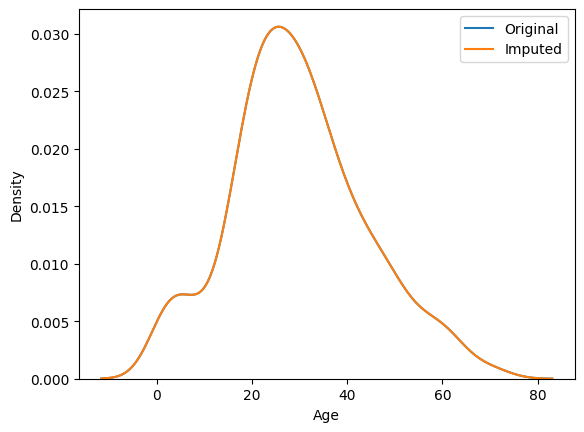

In [17]:
# Plot original vs imputed Age distribution
# Good imputation = both curves should look similar (same shape)
# Random sample imputation preserves distribution better than mean/median
sns.kdeplot(X_train['Age'].dropna(), label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [18]:
# Compare variance before and after imputation
# Good imputation = variance should stay similar
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  204.34951339046142


In [19]:
# Check covariance between Fare, Age and Age_imputed
# Good imputation = relationship between columns should be preserved
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,71.512440
Age,71.512440,204.349513,204.349513
Age_imputed,71.512440,204.349513,204.349513


<Axes: >

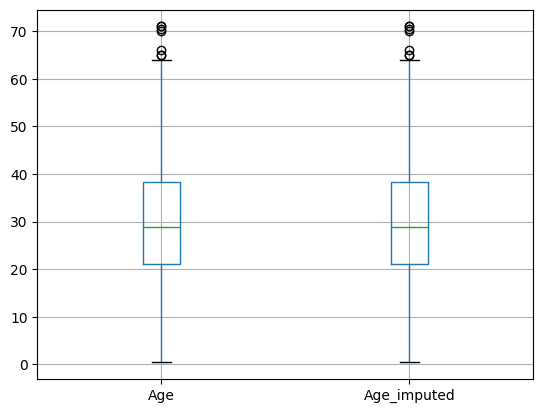

In [20]:
# Boxplot comparison of Age vs Age_imputed
# The median and spread should look very similar
X_train[['Age', 'Age_imputed']].boxplot()

## Now applying Random Sample Imputation on House Prices dataset (categorical columns)

In [24]:
# Load house prices dataset — using GarageQual and FireplaceQu (categorical columns with missing values)
data = pd.read_csv('house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [25]:
# Preview first 5 rows
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [26]:
# Check percentage of missing values — both columns have a lot of missing data
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [27]:
# Separate features and target
X = data
y = data['SalePrice']

In [28]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [29]:
# Create imputed copies of both categorical columns
X_train = X_train.copy()
X_test = X_test.copy()
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [45]:
# Preview sample of training data before imputation
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,Gd
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [36]:
# Apply random sample imputation to both categorical columns

# GarageQual
garage_train_missing = X_train['GarageQual_imputed'].isnull().sum()
garage_test_missing  = X_test['GarageQual_imputed'].isnull().sum()

garage_train_samples = X_train['GarageQual'].dropna().sample(garage_train_missing).values
garage_test_samples  = X_train['GarageQual'].dropna().sample(garage_test_missing).values

X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = garage_train_samples
X_test.loc[X_test['GarageQual_imputed'].isnull(),   'GarageQual_imputed'] = garage_test_samples

# FireplaceQu
fireplace_train_missing = X_train['FireplaceQu_imputed'].isnull().sum()
fireplace_test_missing  = X_test['FireplaceQu_imputed'].isnull().sum()

fireplace_train_samples = X_train['FireplaceQu'].dropna().sample(fireplace_train_missing).values
fireplace_test_samples  = X_train['FireplaceQu'].dropna().sample(fireplace_test_missing).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = fireplace_train_samples
X_test.loc[X_test['FireplaceQu_imputed'].isnull(),   'FireplaceQu_imputed'] = fireplace_test_samples

In [44]:
# Compare category proportions before and after imputation for GarageQual
# Good imputation = proportions should stay very similar
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ],
    axis=1)

temp.columns = ['original', 'imputed']


print(X_train['GarageQual'].value_counts())
print(len(X_train['GarageQual'].dropna()))
print(X_train['GarageQual_imputed'].value_counts())
print(len(X_train))
temp

GarageQual
TA    1049
Fa      41
Gd      11
Po       1
Ex       1
Name: count, dtype: int64
1103
GarageQual_imputed
TA    1113
Fa      41
Gd      12
Po       1
Ex       1
Name: count, dtype: int64
1168


,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035103
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [33]:
# Compare category proportions before and after imputation for FireplaceQu
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
    ],
    axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
Gd,0.494272,0.258562
TA,0.412439,0.215753
Fa,0.040917,0.021404
Po,0.027823,0.014555
Ex,0.024550,0.012842


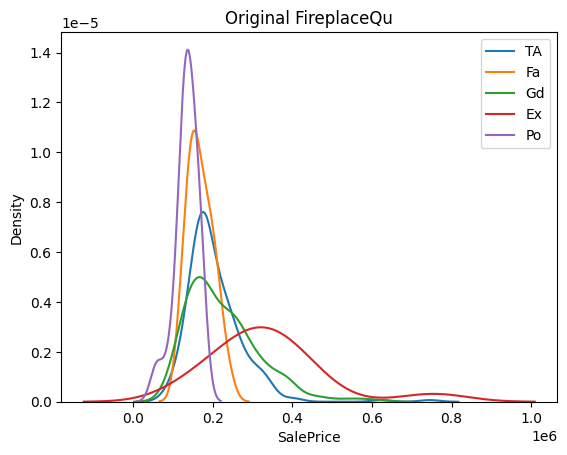

In [46]:
# Plot SalePrice distribution per FireplaceQu category (original)
# Check if each category has a distinct SalePrice range
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category)
plt.title('Original FireplaceQu')
plt.legend()
plt.show()

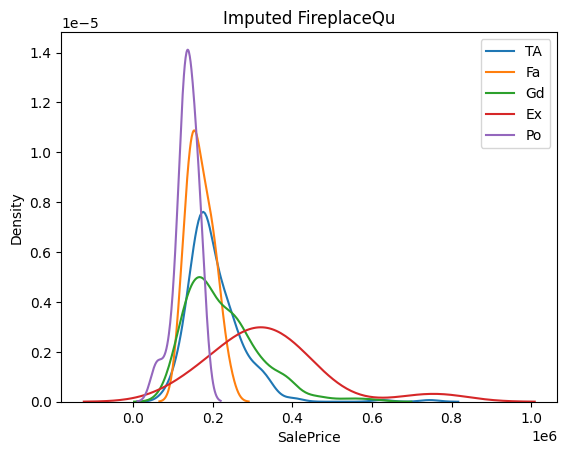

In [35]:
# Plot SalePrice distribution per FireplaceQu_imputed category (after imputation)
# Should look similar to the original — confirms imputation preserved the data pattern
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)
plt.title('Imputed FireplaceQu')
plt.legend()
plt.show()